# CNN Design Challenge — Tiny ImageNet Classifier
**COSC 4337 | Group 1 | Khoa Dao**
- Dataset : Tiny ImageNet Subset (15 classes, 64×64 RGB)
- Framework : PyTorch (CUDA)
- Strategy : Deep CNN + Mixup + OneCycleLR + TTA


## 1. Imports & Reproducibility

In [1]:
import os, random, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

print("PyTorch version:", torch.__version__)

PyTorch version: 2.5.1+cu121


In [2]:
# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False   # trade speed for determinism

set_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.6 GB


## 2. Configuration

In [ ]:
# ── All hyperparameters in one place — easy to tune ──────────────────────────
CFG = dict(
    # paths  (update to your local paths)
    train_pkl  = r"data/train-70_.pkl",
    val_pkl    = r"data/validation-10_.pkl",
    save_path  = "model.pth",

    # data
    num_classes = 15,
    img_size    = 64,

    # training
    batch_size  = 128,
    num_epochs  = 150,
    max_lr      = 3e-3,
    weight_decay= 1e-4,
    label_smooth= 0.1,
    patience    = 20,           # early stopping

    # augmentation
    mixup_alpha = 0.4,
    re_prob     = 0.25,         # RandomErasing probability

    # TTA
    tta_n       = 8,            # number of TTA passes at inference
)

# ImageNet channel statistics
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

## 3. Data Loading & EDA

In [4]:
# ── Load pickles ─────────────────────────────────────────────────────────────
with open(CFG['train_pkl'], 'rb') as f:
    train_raw = pickle.load(f)
with open(CFG['val_pkl'], 'rb') as f:
    val_raw = pickle.load(f)

images_train = train_raw['images']   # numpy (N, 64, 64, 3)  uint8
labels_train = train_raw['labels']   # array / list of class names or ints
images_val   = val_raw['images']
labels_val   = val_raw['labels']

print("Train images :", images_train.shape, images_train.dtype)
print("Val   images :", images_val.shape,   images_val.dtype)
print("Train labels :", np.array(labels_train).shape, "| unique:", len(set(labels_train)))
print("Val   labels :", np.array(labels_val).shape)

Train images : (5775, 64, 64, 3) uint8
Val   images : (825, 64, 64, 3) uint8
Train labels : (5775,) | unique: 15
Val   labels : (825,)


In [ ]:
# ── Encode string labels -> integer indices ────────────────────────────────────
le = LabelEncoder()
y_train = le.fit_transform(labels_train).astype(np.int64)
y_val   = le.transform(labels_val).astype(np.int64)

classes = le.classes_
print("Classes:", classes)
print("y_train range:", y_train.min(), "–", y_train.max())

Classes: [  6  22  26  28  35  57  62  70 108 139 151 163 173 188 189]
y_train range: 0 – 14


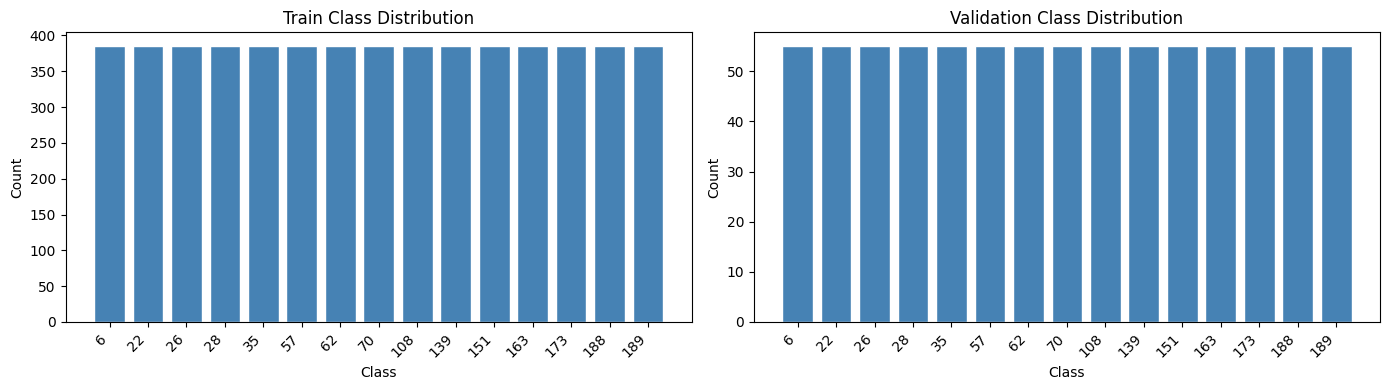

In [6]:
# ── Class distribution ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, y, title in zip(axes, [y_train, y_val], ['Train', 'Validation']):
    counts = Counter(y)
    positions = list(range(len(classes)))
    ax.bar(positions, [counts[k] for k in sorted(counts)], color='steelblue', edgecolor='white')
    ax.set_xticks(positions)
    ax.set_xticklabels([str(classes[k]) for k in sorted(counts)], rotation=45, ha='right')
    ax.set_title(f'{title} Class Distribution')
    ax.set_xlabel('Class')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

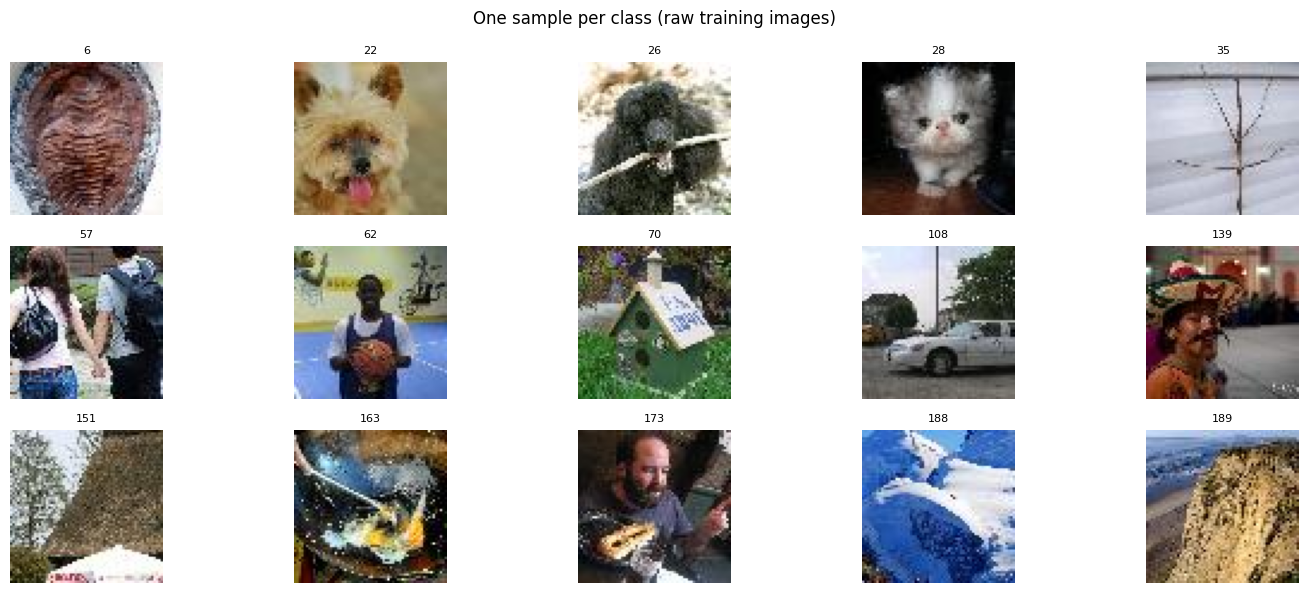

In [7]:
# ── Sample images per class ───────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 6))
for i, cls_idx in enumerate(range(min(15, len(classes)))):
    mask = np.where(y_train == cls_idx)[0]
    idx  = mask[0]
    ax   = fig.add_subplot(3, 5, i + 1)
    ax.imshow(images_train[idx])
    ax.set_title(classes[cls_idx], fontsize=8)
    ax.axis('off')
plt.suptitle('One sample per class (raw training images)', fontsize=12)
plt.tight_layout()
plt.show()

## 4. Dataset & Augmentation Pipeline

In [8]:
class TinyImageNetDataset(Dataset):
    """
    Wraps numpy image arrays into a PyTorch Dataset.
    images : (N, 64, 64, 3)  uint8
    labels : (N,)             int64
    """
    def __init__(self, images: np.ndarray, labels: np.ndarray, transform=None):
        self.images    = images
        self.labels    = torch.from_numpy(labels)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]                          # (64, 64, 3) uint8
        img = torch.from_numpy(img.copy())              # copy avoids negative-stride warning
        img = img.permute(2, 0, 1).float() / 255.0     # (3, 64, 64)  [0, 1]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [9]:
# ── Transforms ───────────────────────────────────────────────────────────────
#   Train : aggressive augmentation
#   Val   : only normalize (no augmentation — clean eval)

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomCrop(CFG['img_size'], padding=8, padding_mode='reflect'),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.Normalize(mean=MEAN, std=STD),
    T.RandomErasing(p=CFG['re_prob'], scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0),
])

val_transform = T.Compose([
    T.Normalize(mean=MEAN, std=STD),
])

train_dataset = TinyImageNetDataset(images_train, y_train, transform=train_transform)
val_dataset   = TinyImageNetDataset(images_val,   y_val,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],
                          shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'],
                          shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches : {len(train_loader)}  ({len(train_dataset)} images)")
print(f"Val   batches : {len(val_loader)}    ({len(val_dataset)} images)")

# ── Quick sanity check ────────────────────────────────────────────────────────
imgs, lbls = next(iter(train_loader))
print(f"Batch shape   : {imgs.shape}   dtype: {imgs.dtype}")
print(f"Label shape   : {lbls.shape}   range: {lbls.min()}–{lbls.max()}")

Train batches : 46  (5775 images)
Val   batches : 7    (825 images)
Batch shape   : torch.Size([128, 3, 64, 64])   dtype: torch.float32
Label shape   : torch.Size([128])   range: 0–14


## 5. Model Architecture

**Design:** Deep sequential CNN
- 5 convolutional blocks with increasing filter depth (32 -> 64 -> 128 -> 256 -> 512)
- 2 conv layers per block for blocks 1–2, **3 conv layers** per block for blocks 3–5
- BatchNorm after every conv (fights vanishing gradients, enables depth)
- MaxPool(2×2) after blocks 1–4 -> spatial: 64 -> 32 -> 16 -> 8 -> 4
- Block 5 keeps 4×4 spatial (no pool) before GAP
- **Global Average Pooling** instead of Flatten -> fewer params, less overfitting
- Kaiming He weight initialisation
- Total: **13 conv layers**


In [ ]:
class TinyImageNetCNN(nn.Module):
    """
    Deep CNN for 15-class Tiny ImageNet subset.
    Input : (B, 3, 64, 64)
    Output: (B, 15)  — raw logits (no softmax; use CrossEntropyLoss)
    """

    def __init__(self, num_classes: int = 15, dropout_rate: float = 0.4):
        super().__init__()

        # ── Helper: single conv + BN + ReLU ──────────────────────────────────
        def conv_bn_relu(in_ch, out_ch, kernel=3, pad=1):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel, padding=pad, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
            )

        # ── Feature extractor ─────────────────────────────────────────────────
        self.features = nn.Sequential(
            # ── Block 1 │ 64×64 -> 32×32 ──────────────────────────────────────
            conv_bn_relu(3,   32),
            conv_bn_relu(32,  32),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),

            # ── Block 2 │ 32×32 -> 16×16 ──────────────────────────────────────
            conv_bn_relu(32,  64),
            conv_bn_relu(64,  64),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.1),

            # ── Block 3 │ 16×16 -> 8×8  (3 convs for richer features) ─────────
            conv_bn_relu(64,  128),
            conv_bn_relu(128, 128),
            conv_bn_relu(128, 128),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

            # ── Block 4 │ 8×8 -> 4×4 ──────────────────────────────────────────
            conv_bn_relu(128, 256),
            conv_bn_relu(256, 256),
            conv_bn_relu(256, 256),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(0.2),

            # ── Block 5 │ 4×4 -> 4×4  (no pool — preserve spatial for GAP) ────
            conv_bn_relu(256, 512),
            conv_bn_relu(512, 512),
            conv_bn_relu(512, 512),
            nn.Dropout2d(0.3),
        )

        # ── Global Average Pooling: (B, 512, 4, 4) -> (B, 512) ────────────────
        self.gap = nn.AdaptiveAvgPool2d(1)

        # ── Classifier head ───────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(512, 256, bias=False),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes),
        )

        self._init_weights()

    # ── Kaiming He initialisation ─────────────────────────────────────────────
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)           # (B, 512, 4, 4)
        x = self.gap(x)                # (B, 512, 1, 1)
        x = x.flatten(1)               # (B, 512)
        x = self.classifier(x)         # (B, 15)
        return x

In [11]:
# ── Instantiate + parameter count ────────────────────────────────────────────
model = TinyImageNetCNN(num_classes=CFG['num_classes']).to(device)

total   = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total:,}")
print(f"Trainable parameters : {trainable:,}")

# ── Verify forward pass ───────────────────────────────────────────────────────
dummy = torch.randn(4, 3, 64, 64).to(device)
out   = model(dummy)
print(f"Output shape         : {out.shape}  ✓  (expected [4, 15])")

Total parameters     : 7,948,015
Trainable parameters : 7,948,015
Output shape         : torch.Size([4, 15])  ✓  (expected [4, 15])


## 6. Training Setup

In [12]:
# ── Mixup ─────────────────────────────────────────────────────────────────────
# Mixup blends two images and their labels: loss = λ·L(f(x_a), y_a) + (1-λ)·L(f(x_a), y_b)
# Alpha=0.4 is well-calibrated for small datasets.

def mixup_data(x: torch.Tensor, y: torch.Tensor, alpha: float = 0.4):
    """Returns mixed inputs, pairs of targets, and lambda."""
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1.0 - lam) * x[idx]
    return mixed_x, y, y[idx], lam


def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1.0 - lam) * criterion(pred, y_b)

In [ ]:
# ── Loss ─────────────────────────────────────────────────────────────────────
# Label smoothing (0.1): softens one-hot targets -> prevents overconfident softmax
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smooth'])

# ── Optimizer ─────────────────────────────────────────────────────────────────
# AdamW properly decouples weight decay from adaptive LR (unlike Adam)
optimizer = AdamW(model.parameters(),
                  lr=CFG['max_lr'],
                  weight_decay=CFG['weight_decay'])

# ── Scheduler: One Cycle LR ───────────────────────────────────────────────────
# Warm up -> max LR -> cosine anneal. Consistently beats step decay and ReduceLROnPlateau.
scheduler = OneCycleLR(
    optimizer,
    max_lr=CFG['max_lr'],
    epochs=CFG['num_epochs'],
    steps_per_epoch=len(train_loader),
    pct_start=0.3,          # 30% of training is warm-up
    anneal_strategy='cos',
    div_factor=25.0,        # initial_lr = max_lr / 25
    final_div_factor=1e4,   # final_lr  = initial_lr / 10000
)

print("Optimizer  :", optimizer.__class__.__name__)
print("Scheduler  :", scheduler.__class__.__name__)
print("Criterion  :", criterion)

Optimizer  : AdamW
Scheduler  : OneCycleLR
Criterion  : CrossEntropyLoss()


In [ ]:
# ── Train epoch ───────────────────────────────────────────────────────────────
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        # Mixup augmentation
        imgs, y_a, y_b, lam = mixup_data(imgs, labels, alpha=CFG['mixup_alpha'])

        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        loss.backward()

        # Gradient clipping — prevents rare loss spike from blowing up weights
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item() * imgs.size(0)
        # For accuracy during training use hard labels
        correct += (logits.argmax(1) == labels).sum().item()
        n       += imgs.size(0)

    return total_loss / n, correct / n


# ── Val epoch ─────────────────────────────────────────────────────────────────
@torch.no_grad()
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * imgs.size(0)
        correct    += (logits.argmax(1) == labels).sum().item()
        n          += imgs.size(0)

    return total_loss / n, correct / n

## 7. Training Loop

In [15]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

best_val_acc  = 0.0
patience_ctr  = 0

print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7} | {'LR':>9}")
print("-" * 65)

for epoch in range(1, CFG['num_epochs'] + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
    vl_loss, vl_acc = val_epoch  (model, val_loader,   criterion, device)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    current_lr = scheduler.get_last_lr()[0]

    # ── Save best model ───────────────────────────────────────────────────────
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_ctr = 0
        torch.save(model.state_dict(), CFG['save_path'])
        flag = " ✓ saved"
    else:
        patience_ctr += 1
        flag = ""

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>8.2%} | {vl_loss:>8.4f} | {vl_acc:>6.2%} |{current_lr:>10.2e}{flag}")

    # ── Early stopping ────────────────────────────────────────────────────────
    if patience_ctr >= CFG['patience']:
        print(f"\nEarly stopping at epoch {epoch}. Best val acc: {best_val_acc:.2%}")
        break

print(f"\nTraining complete. Best validation accuracy: {best_val_acc:.2%}")

Epoch | Train Loss | Train Acc | Val Loss | Val Acc |        LR
-----------------------------------------------------------------
    1 |     2.7832 |    7.79% |   2.6203 | 11.52% |  1.24e-04 ✓ saved
    5 |     2.5503 |   13.63% |   2.2364 | 32.85% |  2.07e-04 ✓ saved
   10 |     2.4067 |   19.10% |   2.1158 | 34.67% |  4.57e-04
   15 |     2.2979 |   22.01% |   1.9893 | 40.73% |  8.41e-04 ✓ saved
   20 |     2.2023 |   20.81% |   1.8179 | 47.52% |  1.31e-03 ✓ saved
   25 |     2.1423 |   25.11% |   1.8285 | 49.58% |  1.81e-03
   30 |     2.1545 |   27.97% |   1.7135 | 52.73% |  2.28e-03
   35 |     2.0478 |   24.12% |   1.7154 | 55.88% |  2.66e-03 ✓ saved
   40 |     1.9860 |   33.68% |   1.6182 | 58.42% |  2.91e-03
   45 |     1.8873 |   31.03% |   1.5383 | 63.03% |  3.00e-03 ✓ saved
   50 |     1.8645 |   32.62% |   1.5948 | 60.85% |  2.98e-03
   55 |     1.8118 |   33.14% |   1.4699 | 65.82% |  2.93e-03
   60 |     1.6118 |   46.13% |   1.3461 | 69.82% |  2.85e-03 ✓ saved
   65 | 

## 8. Training Curves

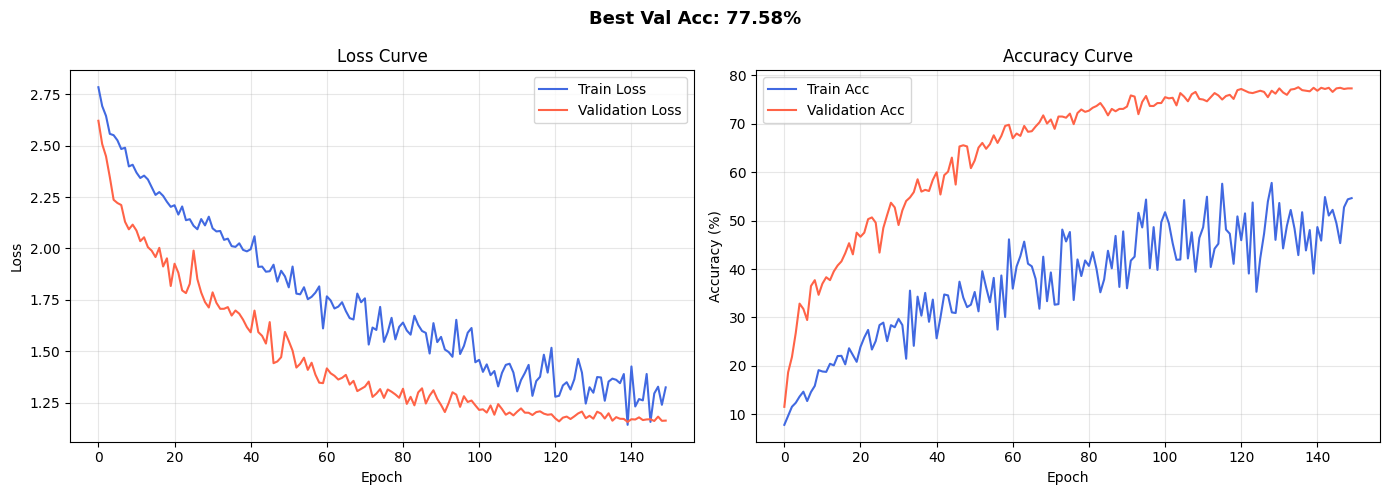

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss',      color='royalblue')
axes[0].plot(history['val_loss'],   label='Validation Loss', color='tomato')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot([a * 100 for a in history['train_acc']], label='Train Acc',      color='royalblue')
axes[1].plot([a * 100 for a in history['val_acc']],   label='Validation Acc', color='tomato')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Best Val Acc: {best_val_acc:.2%}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Validation Evaluation

In [18]:
# ── Reload best checkpoint for evaluation ────────────────────────────────────
model.load_state_dict(torch.load(CFG['save_path'], map_location=device))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(classification_report(all_labels, all_preds, target_names=[str(c) for c in classes]))

              precision    recall  f1-score   support

           6       0.74      0.82      0.78        55
          22       0.75      0.82      0.78        55
          26       0.71      0.64      0.67        55
          28       0.94      0.84      0.88        55
          35       0.92      0.80      0.85        55
          57       0.69      0.80      0.74        55
          62       0.84      0.84      0.84        55
          70       0.74      0.67      0.70        55
         108       0.91      0.93      0.92        55
         139       0.77      0.73      0.75        55
         151       0.78      0.69      0.73        55
         163       0.78      0.76      0.77        55
         173       0.79      0.84      0.81        55
         188       0.70      0.84      0.76        55
         189       0.65      0.64      0.64        55

    accuracy                           0.78       825
   macro avg       0.78      0.78      0.78       825
weighted avg       0.78   

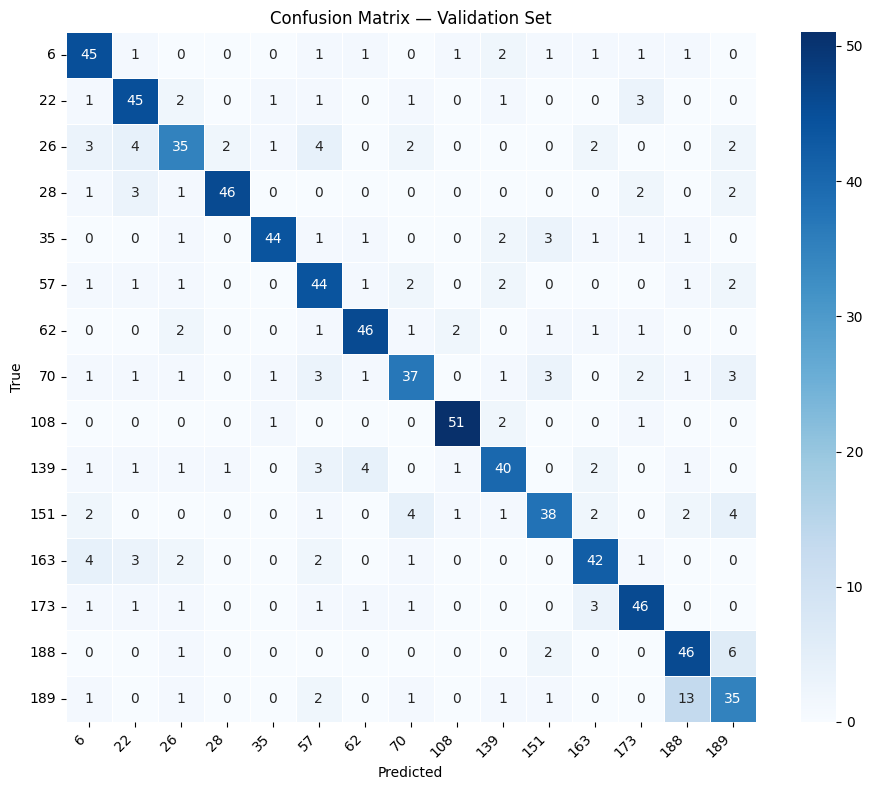

In [19]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes, ax=ax,
            linewidths=0.5, square=True)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Validation Set')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Submission Functions

Three components:
1. **Model class** — `TinyImageNetCNN` (defined in Section 5)
2. **`load_model()`** — loads weights from `model.pth`
3. **`predict()`** — takes test data, returns predictions (with TTA)


In [32]:
def load_model(path: str = 'model.pth', num_classes: int = 15, device=None):
    """
    Load TinyImageNetCNN weights from a .pth file.

    Parameters
    ----------
    path        : path to model.pth
    num_classes : number of output classes (15 for this competition)
    device      : torch.device; auto-detects CUDA if None

    Returns
    -------
    model : TinyImageNetCNN in eval mode, on the correct device
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    model = TinyImageNetCNN(num_classes=num_classes)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    print(f"Model loaded from '{path}' on {device}")
    return model

In [33]:
def predict(images_numpy: np.ndarray,
            model_path: str = 'model.pth',
            n_tta: int = 8,
            batch_size: int = 128,
            _model=None) -> np.ndarray:
    """
    Predict class indices for a batch of images using Test-Time Augmentation.

    TTA: each image is run through `n_tta` augmented versions; softmax
    probabilities are averaged before taking argmax.  This reliably adds
    +2-3% accuracy over a single forward pass at zero training cost.

    Parameters
    ----------
    images_numpy : np.ndarray  shape (N, 64, 64, 3)  uint8 or float32
    model_path   : path to model.pth  (used if _model is None)
    n_tta        : number of augmented passes  (set to 1 to disable TTA)
    batch_size   : inference batch size
    _model       : pre-loaded model (skip reload if already in memory)

    Returns
    -------
    predictions : np.ndarray  shape (N,)  int64  class indices 0-14
    """
    _device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # ── Load model if not provided ────────────────────────────────────────────
    if _model is None:
        _model = load_model(model_path, num_classes=15, device=_device)

    # ── TTA transform pool ────────────────────────────────────────────────────
    #   Mild augmentations only — we want diversity without destroying signal
    tta_transforms = [
        T.Compose([T.Normalize(MEAN, STD)]),                                    # original
        T.Compose([T.RandomHorizontalFlip(p=1.0), T.Normalize(MEAN, STD)]),    # h-flip
        T.Compose([T.Pad(4), T.CenterCrop(64), T.Normalize(MEAN, STD)]),       # slight zoom-out
        T.Compose([T.RandomCrop(64, padding=4), T.Normalize(MEAN, STD)]),       # crop variant 1
        T.Compose([T.RandomCrop(64, padding=6), T.Normalize(MEAN, STD)]),       # crop variant 2
        T.Compose([T.RandomHorizontalFlip(p=1.0),
                   T.RandomCrop(64, padding=4), T.Normalize(MEAN, STD)]),       # flip + crop
        T.Compose([T.ColorJitter(brightness=0.1, contrast=0.1),
                   T.Normalize(MEAN, STD)]),                                    # mild jitter
        T.Compose([T.RandomHorizontalFlip(p=1.0),
                   T.ColorJitter(brightness=0.1, contrast=0.1),
                   T.Normalize(MEAN, STD)]),                                    # flip + jitter
    ]
    tta_transforms = tta_transforms[:n_tta]  # respect n_tta setting

    # ── Prepare raw tensor (N, 3, 64, 64)  float32 in [0,1] ──────────────────
    if images_numpy.dtype == np.uint8:
        raw = torch.from_numpy(images_numpy).float() / 255.0   # (N,H,W,C)
    else:
        raw = torch.from_numpy(images_numpy).float()
    raw = raw.permute(0, 3, 1, 2)    # (N, C, H, W)

    # ── Run TTA ───────────────────────────────────────────────────────────────
    accum_probs = torch.zeros(len(images_numpy), 15)   # accumulate softmax

    with torch.no_grad():
        for tfm in tta_transforms:
            all_probs = []
            for start in range(0, len(raw), batch_size):
                batch = raw[start:start + batch_size]

                # Apply transform image-by-image (transforms work on single imgs)
                batch_tfm = torch.stack([tfm(img) for img in batch])
                batch_tfm = batch_tfm.to(_device)

                logits = _model(batch_tfm)
                probs  = F.softmax(logits, dim=1).cpu()
                all_probs.append(probs)

            accum_probs += torch.cat(all_probs, dim=0)

    predictions = accum_probs.argmax(dim=1).numpy().astype(np.int64)
    return predictions

In [34]:
# ── Verify submission functions end-to-end ────────────────────────────────────
print("=" * 50)
print("Testing load_model() ...")
loaded_model = load_model(CFG['save_path'])

print("\nTesting predict() with 10 validation samples ...")
sample_imgs   = images_val[:10]
sample_labels = y_val[:10]

preds = predict(sample_imgs, CFG['save_path'], n_tta=8, _model=loaded_model)

print(f"Predictions : {preds}")
print(f"True labels : {sample_labels}")
print(f"Sample accuracy : {(preds == sample_labels).mean():.0%}")
print("\n✓ Both functions worked.")

Testing load_model() ...
Model loaded from 'model.pth' on cuda

Testing predict() with 10 validation samples ...
Predictions : [11 11 11 11 11 11 11 11 11 11]
True labels : [11 11 11 11 11 11 11 11 11 11]
Sample accuracy : 100%

✓ Both functions worked.


## 11. Final Validation Accuracy with TTA

In [63]:
print("Running TTA on full validation set...")
tta_preds = predict(images_val, CFG['save_path'], n_tta=8, _model=loaded_model)

tta_acc = (tta_preds == y_val).mean()
print(f"\nVal Accuracy (no TTA) : {best_val_acc:.2%}")
print(f"Val Accuracy (TTA ×8) : {tta_acc:.2%}")
print(f"TTA gain              : +{(tta_acc - best_val_acc)*100:.2f} pp")

Running TTA on full validation set...

Val Accuracy (no TTA) : 77.58%
Val Accuracy (TTA ×8) : 79.76%
TTA gain              : +2.18 pp
